Title: Temp_average.ipynb

Purpose: Calculate a temperature average and find periods of temperature minima

Author: PP / Onno Nennecke on 16 January 2025 Modified: 17 January 2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

Import packages

In [1]:
import xarray as xr
import numpy as np

Load data

In [ ]:
ESM = 'BHISTcmip6'
run = 'LE2-1001.001'
variable = 'TREFHT' # Temperature at Reference Height
nc = xr.open_mfdataset(f'/climca/data/CESM2_LE/TREFHT/day_raw/b.e21.{ESM}.f09_g17.{run}.cam.h1.{variable}.*')

In [3]:
# select variable
tas = nc['TREFHT'] # Temperature at Reference Height
tas

<xarray.DataArray 'TREFHT' (time: 60226, lat: 192, lon: 288)> Size: 13GB
dask.array<concatenate, shape=(60226, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [4]:
# filter winter
tas = tas[np.isin(tas.time.dt.month, [12,1,2]),:,:]
# tas

In [5]:
# select region
tas = tas.sel(dict(lat=slice(45,60), lon=slice(5,15)))
# tas

In [6]:
# Apply weighted mean
weights = np.cos(np.radians(tas.lat))
tas_reg_avg = tas.weighted(weights).mean(('lat','lon'))
tas_reg_avg

<xarray.DataArray 'TREFHT' (time: 14851)> Size: 119kB
dask.array<truediv, shape=(14851,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 119kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [16]:
# Zwischenergebnis speichern
xr.Dataset({'TREFHT':tas_reg_avg}).to_netcdf('/climca/people/onennecke/TREFHT_reg_mean.nc')

In [7]:
tas_reg_avg = xr.open_dataarray('/climca/people/onennecke/TREFHT_reg_mean.nc')
tas_reg_avg

<xarray.DataArray 'TREFHT' (time: 14851)> Size: 119kB
[14851 values with dtype=float64]
Coordinates:
  * time     (time) object 119kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00

In [8]:
import matplotlib.pyplot as plt
import cartopy

In [9]:
# aufpassen mit Feb -> Dez
tas_reg_avg_roll = tas_reg_avg.rolling(time=7, center=False).mean()

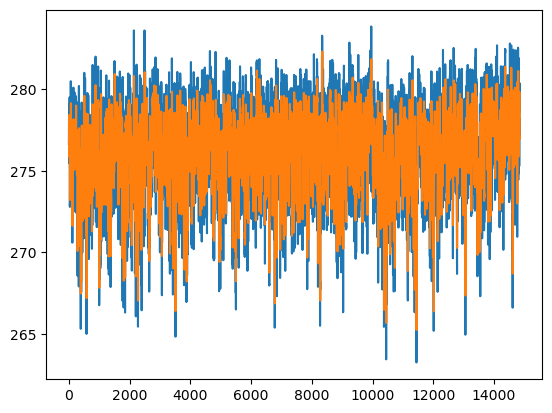

In [10]:
plt.plot(tas_reg_avg)
plt.plot(tas_reg_avg_roll)

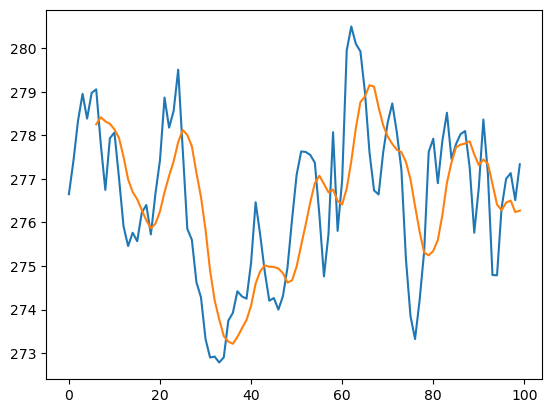

In [11]:
plt.plot(tas_reg_avg[:100])
plt.plot(tas_reg_avg_roll[:100])

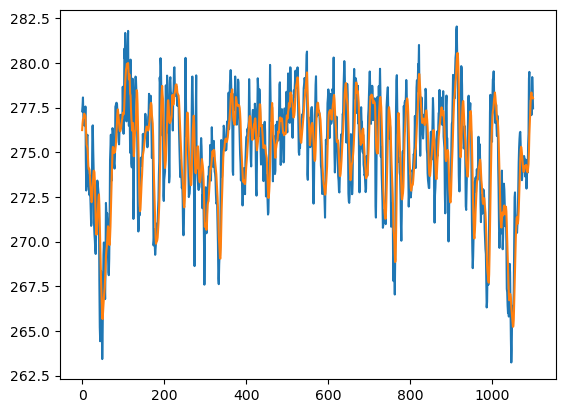

In [12]:
plt.plot(tas_reg_avg[10400:11500])
plt.plot(tas_reg_avg_roll[10400:11500])

In [13]:
lowest_indices = np.argsort(tas_reg_avg_roll.values)[:10]
lowest_indices
# tas_reg_avg_roll[lowest_indices]

array([11450, 11451, 11449, 11452, 10450, 10449, 11448, 10451, 11447,
       10448])

In [ ]:
# plot PSL and Z500 maps for 10 most extreme temperatures

variable = 'PSL' # Temperature at Reference Height
nc_psl = xr.open_mfdataset(f'/climca/data/CESM2_LE/{variable}/day_raw/b.e21.{ESM}.f09_g17.{run}.cam.h1.{variable}.*')

In [15]:
nc_psl

<xarray.Dataset> Size: 13GB
Dimensions:       (time: 60226, lat: 192, lev: 32, ilev: 33, nbnd: 2, lon: 288)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 482kB 1850-01-01 00:00:00 ... 2015-01-01 00:0...
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (time, lat) float64 93MB dask.array<chunksize=(3650, 192), meta=np.ndarray>
    hyam          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    hybm          (time, lev) float64 15MB dask.array<chunksize=(3650, 32), meta=np.ndarray>
    P0            (time) float64 482kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    hybi          (time, ilev) float64 16MB dask.array<chunksize=(3650, 33), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f11vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    f12vmr        (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    sol_tsi       (time) float64 482kB dask.array<chunksize=(512,), meta=np.ndarray>
    nsteph        (time) float64 482kB dask.array<chunksize=(1024,), meta=np.ndarray>
    PSL           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTcmip6.f09_g17.LE2-1001.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1001-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [16]:
nc_psl

# select variable
psl = nc_psl['PSL'] # Temperature at Reference Height

# filter winter
psl = psl[np.isin(psl.time.dt.month, [12,1,2]),:,:]
# psl

# select region
psl_1 = psl.sel(dict(lat=slice(10,90), lon= slice(280,360)))
psl_2 = psl.sel(dict(lat=slice(10,90), lon= slice(0,40)))

psl = xr.concat([psl_1, psl_2], dim='lon')


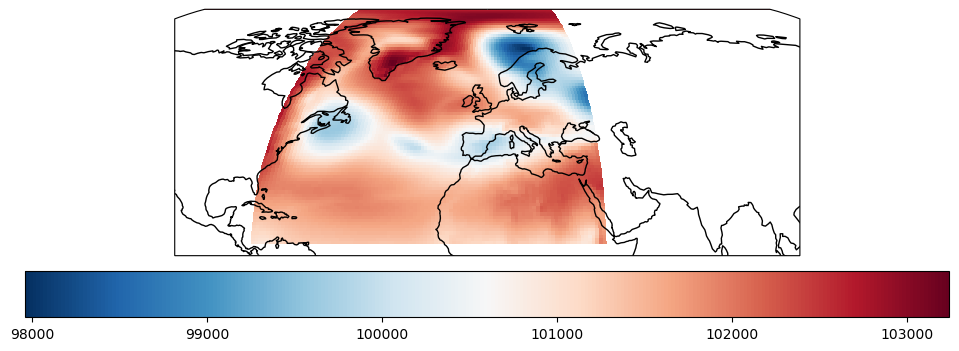

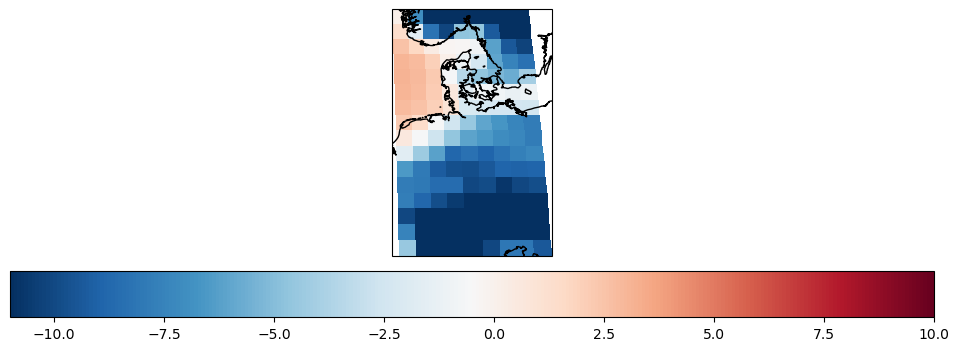

In [17]:
timestep = 11450

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': cartopy.crs.Robinson()})
ax.coastlines()
xxx = psl.isel(time=timestep)
im = ax.pcolormesh(xxx.lon, xxx.lat, xxx, transform=cartopy.crs.PlateCarree(), cmap='RdBu_r')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)

fig,ax = plt.subplots(nrows=1, figsize=(12, 4), subplot_kw={'projection': cartopy.crs.Robinson()})
ax.coastlines()
xxx = tas.isel(time=timestep)

vmin = -11
vmax = 10

im = ax.pcolormesh(xxx.lon, xxx.lat, xxx - 273.15, transform=cartopy.crs.PlateCarree(), cmap='RdBu_r', vmin=vmin,vmax=vmax)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)


In [18]:
tas.isel(time=11450)

<xarray.DataArray 'TREFHT' (lat: 16, lon: 9)> Size: 576B
dask.array<getitem, shape=(16, 9), dtype=float32, chunksize=(16, 9), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
    time     object 8B 1977-01-21 00:00:00
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean